This assignment implements:

✅ A 3-layer deep neural network using PyTorch’s built-in functionality

* Uses torch.nn.Module to define the model.
* Uses torch.nn.Linear for layers.
* Uses torch.optim.Adam for backpropagation & weight updates.

✅ Uses a 3-variable non-linear equation for synthetic data generation

Equation:
𝑦
=
2
sin
⁡
(
𝑋
1
)
+
0.5
𝑋
2
2
+
0.3
𝑋
3
3
+
cos
⁡
(
𝑋
1
⋅
𝑋
2
)
+
noise

Visualizes the generated data before training using a 4D plot.

✅ Trains the model with built-in loss function and backpropagation

* Uses MSE Loss (torch.nn.MSELoss).
* Uses Adam optimizer (torch.optim.Adam).

✅ Visualizes Training Results & Model Performance

* Training loss curve.
* 4D scatter plot of predictions.
* Actual vs. Predicted Values plot.
* Predictions on new test points.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# Generate synthetic non-linear data with 3 variables
def generate_data(n_samples=1000):
    X1 = np.random.uniform(-5, 5, n_samples)
    X2 = np.random.uniform(-5, 5, n_samples)
    X3 = np.random.uniform(-5, 5, n_samples)

    # Complex non-linear equation with 3 variables
    y = (2 * np.sin(X1) + 0.5 * X2**2 + 0.3 * X3**3 +
         np.cos(X1 * X2) + np.random.normal(0, 0.2, n_samples))

    X = np.column_stack((X1, X2, X3))
    return torch.FloatTensor(X), torch.FloatTensor(y.reshape(-1, 1))

In [ ]:
# Define a 3-layer deep neural network using PyTorch's nn.Module
class ThreeLayerNN(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super(ThreeLayerNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden1_size)
        self.layer2 = nn.Linear(hidden1_size, hidden2_size)
        self.output_layer = nn.Linear(hidden2_size, output_size)
        self.relu = nn.ReLU()  # Activation function

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

In [ ]:
# Function to train the model
def train_model(model, X_train, y_train, learning_rate=0.01, epochs=1000):
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

    return losses

In [ ]:
# Generate synthetic data
X_train, y_train = generate_data(1000)

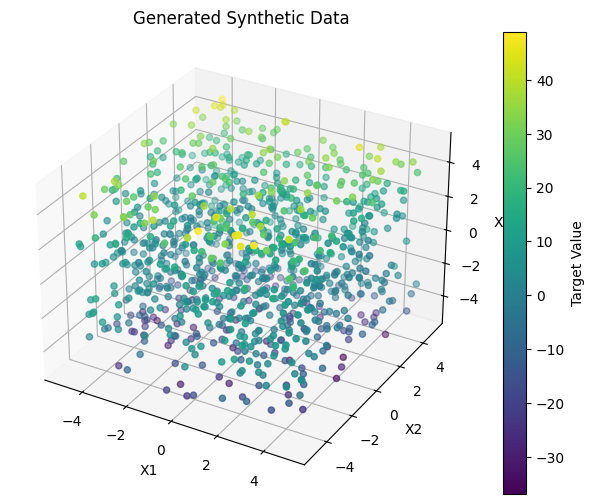

In [ ]:
# Plot the generated synthetic data before training
def plot_synthetic_data(X_train, y_train):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train.numpy(), cmap='viridis')
    plt.colorbar(scatter, label='Target Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Generated Synthetic Data')
    plt.show()

plot_synthetic_data(X_train, y_train)


In [ ]:
# Create the model instance
model = ThreeLayerNN(input_size=3, hidden1_size=64, hidden2_size=32, output_size=1)


In [ ]:
# Train the model
losses = train_model(model, X_train, y_train, learning_rate=0.01, epochs=1000)


Epoch 0, Loss: 248.7046
Epoch 100, Loss: 13.4720
Epoch 200, Loss: 1.3184
Epoch 300, Loss: 0.6658
Epoch 400, Loss: 0.5286
Epoch 500, Loss: 0.4805
Epoch 600, Loss: 0.4522
Epoch 700, Loss: 0.4839
Epoch 800, Loss: 0.4106
Epoch 900, Loss: 0.4660


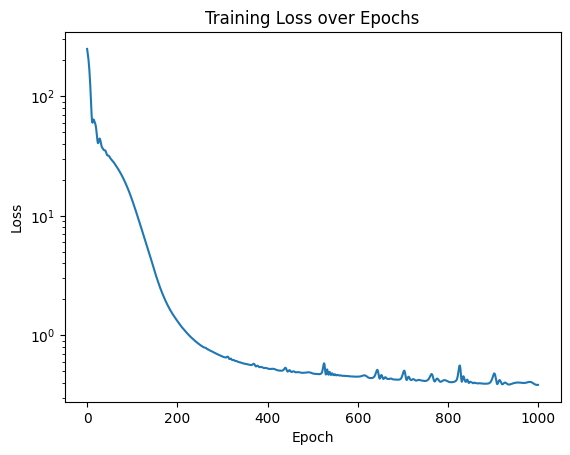

In [ ]:
# Plot Training Loss Curve
def plot_training_loss(losses):
    plt.figure()
    plt.plot(losses)
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.show()

plot_training_loss(losses)

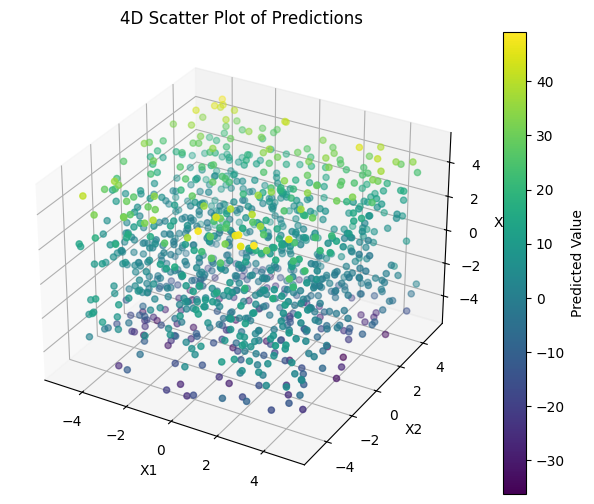

In [ ]:
# Plot 4D scatter of predictions
def plot_4d_scatter(X_train, model):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    with torch.no_grad():
        y_pred = model(X_train)

    scatter = ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_pred.numpy(), cmap='viridis')
    plt.colorbar(scatter, label='Predicted Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('4D Scatter Plot of Predictions')
    plt.show()

plot_4d_scatter(X_train, model)


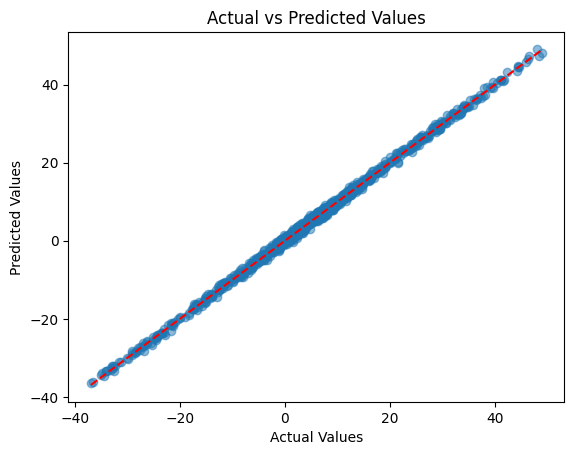

In [ ]:
# Plot Actual vs. Predicted Values
def plot_actual_vs_predicted(y_train, model, X_train):
    with torch.no_grad():
        y_pred = model(X_train)

    plt.figure()
    plt.scatter(y_train.numpy(), y_pred.numpy(), alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.show()

plot_actual_vs_predicted(y_train, model, X_train)

In [ ]:
# Test the model with new data points
def test_model(model, x1, x2, x3):
    with torch.no_grad():
        x_tensor = torch.FloatTensor([[x1, x2, x3]])
        prediction = model(x_tensor)
        return prediction.item()

# Define test points
test_points = [(-4, -4, -4), (-2, -2, -2), (0, 0, 0), (2, 2, 2), (4, 4, 4)]

# Print test predictions
print("\nTest Predictions:")
for x1, x2, x3 in test_points:
    pred = test_model(model, x1, x2, x3)
    actual = 2 * np.sin(x1) + 0.5 * x2**2 + 0.3 * x3**3 + np.cos(x1 * x2)
    print(f"Input: ({x1}, {x2}, {x3})")
    print(f"Prediction: {pred:.3f}")
    print(f"Actual: {actual:.3f}\n")



Test Predictions:
Input: (-4, -4, -4)
Prediction: -9.960
Actual: -10.644

Input: (-2, -2, -2)
Prediction: -2.232
Actual: -2.872

Input: (0, 0, 0)
Prediction: 0.827
Actual: 1.000

Input: (2, 2, 2)
Prediction: 5.948
Actual: 5.565

Input: (4, 4, 4)
Prediction: 25.989
Actual: 24.729

